# Intra vs extra donut blur across the Danish 1.3 blitz FAM ensemble (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-10-03  
**Last Modified:** 2026-10-03  
**Status:** In Progress  
**Keywords:** FAM, donut blur, Danish 1.3, blitz, unpaired, intra-focal, extra-focal, seeing  

## Description

Median donut blur per side of focus against FAM ordinal number, for the whole Danish 1.3
blitz unpaired FAM ensemble, and a test of what kind of offset separates the two sides.

Key functionality:
1. Read the per-side blur medians `median_blur_intra_arcsec` and
   `median_blur_extra_arcsec` from the blitz recast `visits.parquet`.
2. Plot both sides against FAM ordinal number, with a different marker and colour per
   side.
3. Fit three one-parameter models of the intra/extra relation — constant, fractional and
   quadrature — and compare them on robust residual scatter.

The ensemble matters because seeing drifts between the intra-focal and extra-focal
exposures of a single FAM triplet. One triplet cannot separate a real side-of-focus bias
from that drift; 966 triplets can, because the drift averages out while a systematic
offset does not.

**Output:** plots only, written under `output/fam_processing/blur_intra_extra/`.

**Based on:** `aos/docs/studies/fam_processing.md`, the `blitz_reader` recast of the
Danish 1.3 unpaired FAM product into the Danish 1.2 schema. The per-side columns this
notebook reads were added to `blitz_reader.donut_table` and `blitz_reader.visit_metrics`
on 2026-10-03; before that the recast kept only the two-side mean.


## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-10-03 | Aaron Roodman | Initial version |


## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Blur vs FAM ordinal](#ordinal)
6. [What kind of offset?](#offset)
7. [Summary](#summary)


<a id='params'></a>
## Parameters


In [1]:
# ============================================================
# Parameters
# ============================================================

PARAM_SET = 'danish_1_3_test'   # blitz recast of the Danish 1.3 unpaired FAM product
QUALITY_ONLY = True             # keep only visits with visit_quality_pass True
SAVE_PLOTS = True               # write PDFs under output/fam_processing/blur_intra_extra/

# Marker and colour per side of focus, used in every plot below.
SIDE_STYLE = {
    'intra': {'color': '#1f77b4', 'marker': 'o', 'label': 'intra-focal'},
    'extra': {'color': '#d62728', 'marker': '^', 'label': 'extra-focal'},
}


<a id='setup'></a>
## Setup & Imports


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import nmad, setup_plotting

setup_plotting()

OUT_DIR = _TOPIC / 'output' / 'fam_processing' / 'blur_intra_extra'
if SAVE_PLOTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'topic: {_TOPIC}')
print(f'output: {OUT_DIR}')


topic: /sdf/home/r/roodman/notebooks/rubin-work/aos
output: /sdf/home/r/roodman/notebooks/rubin-work/aos/output/fam_processing/blur_intra_extra


<a id='functions'></a>
## Helper Functions


In [3]:
def fit_offset_models(b_intra, b_extra):
    """Fit the three one-parameter models of the intra/extra blur relation.

    Each model has a single free parameter, so their residual scatters are directly
    comparable. Every parameter is estimated with a median rather than a mean, so a
    handful of bad visits cannot drive the comparison.

    Parameters
    ----------
    b_intra, b_extra : `numpy.ndarray`
        Per-visit median donut blur on each side of focus, in arcsec. Same length;
        non-finite entries are dropped pairwise.

    Returns
    -------
    models : `dict`
        One entry per model name (``'constant'``, ``'fractional'``, ``'quadrature'``),
        each a `dict` with ``param`` (the fitted parameter, units in ``param_units``),
        ``param_units``, ``predicted`` (predicted intra blur, arcsec), ``residual``
        (observed minus predicted intra blur, arcsec), ``nmad_arcsec`` (robust residual
        scatter, arcsec) and ``median_abs_arcsec`` (median absolute residual, arcsec).
        The extra key ``n`` is the number of triplets fitted, dimensionless.

    Notes
    -----
    The quadrature parameter is the median of ``b_intra**2 - b_extra**2`` in arcsec**2,
    which is signed: it is negative for an ensemble where intra is the sharper side. The
    predicted blur uses ``sqrt(max(b_extra**2 + q, 0))``.
    """
    b_intra = np.asarray(b_intra, dtype=float)
    b_extra = np.asarray(b_extra, dtype=float)
    ok = np.isfinite(b_intra) & np.isfinite(b_extra)
    bi, be = b_intra[ok], b_extra[ok]

    c = float(np.median(bi - be))
    f = float(np.median(bi / be))
    q = float(np.median(bi**2 - be**2))

    models = {
        'constant': {'param': c, 'param_units': 'arcsec',
                     'predicted': be + c},
        'fractional': {'param': f, 'param_units': 'dimensionless (intra/extra)',
                       'predicted': f * be},
        'quadrature': {'param': q, 'param_units': 'arcsec**2',
                       'predicted': np.sqrt(np.clip(be**2 + q, 0.0, None))},
    }
    for m in models.values():
        m['residual'] = bi - m['predicted']
        m['nmad_arcsec'] = float(nmad(m['residual']))
        m['median_abs_arcsec'] = float(np.median(np.abs(m['residual'])))
    models['n'] = int(ok.sum())
    return models


<a id='data'></a>
## Data Access

`visits.parquet` from the blitz recast carries one row per FAM triplet. The per-side
columns `median_blur_intra_arcsec` and `median_blur_extra_arcsec` are the median over
that side's donuts of the blitz `group_fwhm`, in arcsec; `median_blur_arcsec` is the
median of the two-side mean and is the column the quality cut uses.

The **FAM ordinal number** is the position of the triplet in time order across the whole
ensemble, so it indexes the triplet rather than the exposure.


In [4]:
visits_file = _TOPIC / 'output' / 'fam_processing' / PARAM_SET / 'visits.parquet'
v = pd.read_parquet(visits_file)

needed = ['median_blur_intra_arcsec', 'median_blur_extra_arcsec']
missing = [c for c in needed if c not in v.columns]
if missing:
    raise KeyError(
        f'{visits_file} lacks {missing}; rebuild it with '
        f'`python code/fam_processing/run_blitz_mktable.py --param-set {PARAM_SET} '
        f'--overwrite`, which writes the per-side blur medians')

v = v.sort_values(['day_obs', 'seq_num']).reset_index(drop=True)
print(f'{len(v)} FAM triplets, nights {v["day_obs"].min()} to {v["day_obs"].max()}, '
      f'{v["day_obs"].nunique()} nights')

if QUALITY_ONLY and 'visit_quality_pass' in v.columns:
    n_before = len(v)
    v = v[v['visit_quality_pass'].astype(bool)].reset_index(drop=True)
    print(f'quality cut (visit_quality_pass): kept {len(v)} of {n_before} triplets')

v['fam_ordinal'] = np.arange(1, len(v) + 1)

b_intra = v['median_blur_intra_arcsec'].to_numpy(float)
b_extra = v['median_blur_extra_arcsec'].to_numpy(float)
finite = np.isfinite(b_intra) & np.isfinite(b_extra)
print(f'both sides finite: {int(finite.sum())} of {len(v)} triplets')
print(f'median intra-focal blur = {np.nanmedian(b_intra):.4f} arcsec')
print(f'median extra-focal blur = {np.nanmedian(b_extra):.4f} arcsec')


966 FAM triplets, nights 20260315 to 20260619, 15 nights
quality cut (visit_quality_pass): kept 873 of 966 triplets
both sides finite: 873 of 873 triplets
median intra-focal blur = 1.0526 arcsec
median extra-focal blur = 0.6636 arcsec


<a id='ordinal'></a>
## Blur vs FAM ordinal

Both sides on one axis, intra-focal in blue circles and extra-focal in red triangles.
Night boundaries are drawn in grey, so a run of triplets within one night reads as a
block — seeing drifts within a night, and that drift is the noise this ensemble averages
over.


/lscratch/roodman/ipykernel_2130476/3220836715.py:32: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


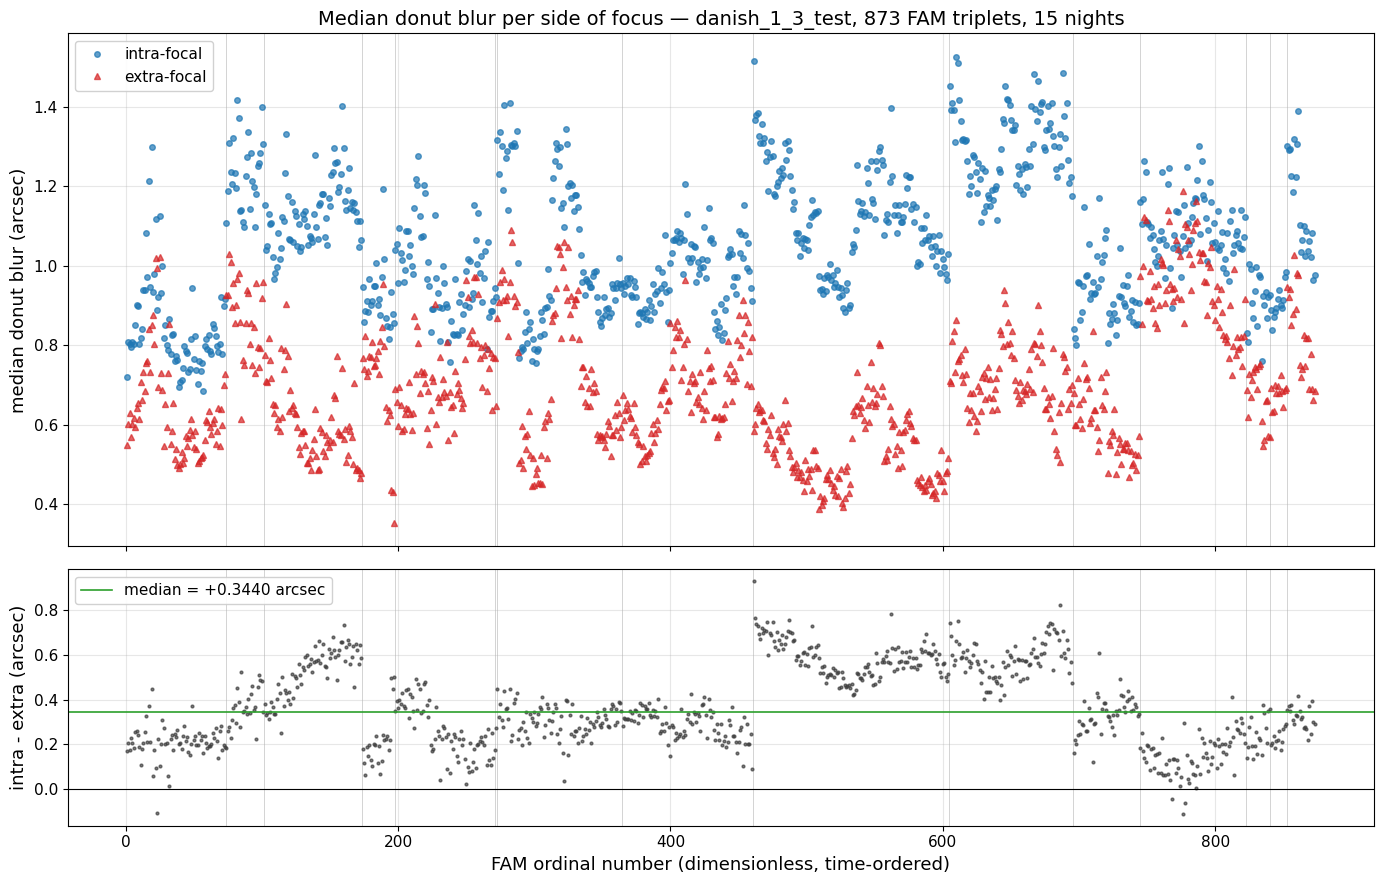

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                        gridspec_kw={'height_ratios': [2, 1]})

ax = axs[0]
for key, values in (('intra', b_intra), ('extra', b_extra)):
    s = SIDE_STYLE[key]
    ax.plot(v['fam_ordinal'], values, linestyle='none', marker=s['marker'],
            color=s['color'], markersize=4, alpha=0.7, label=s['label'])

night_edges = np.flatnonzero(np.diff(v['day_obs'].to_numpy()) != 0) + 1
for e in night_edges:
    ax.axvline(e + 0.5, color='0.8', linewidth=0.6, zorder=0)

ax.set_ylabel('median donut blur (arcsec)')
ax.set_title(f'Median donut blur per side of focus — {PARAM_SET}, '
             f'{len(v)} FAM triplets, {v["day_obs"].nunique()} nights')
ax.legend(loc='upper left', framealpha=0.9)

ax = axs[1]
diff = b_intra - b_extra
ax.plot(v['fam_ordinal'], diff, linestyle='none', marker='.', color='0.25',
        markersize=4, alpha=0.7)
ax.axhline(0.0, color='k', linewidth=0.8)
ax.axhline(float(np.nanmedian(diff)), color='#2ca02c', linewidth=1.2,
           label=f'median = {np.nanmedian(diff):+.4f} arcsec')
for e in night_edges:
    ax.axvline(e + 0.5, color='0.8', linewidth=0.6, zorder=0)
ax.set_xlabel('FAM ordinal number (dimensionless, time-ordered)')
ax.set_ylabel('intra - extra (arcsec)')
ax.legend(loc='upper left', framealpha=0.9)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_vs_fam_ordinal.pdf')
plt.show()


<a id='offset'></a>
## What kind of offset?

Three one-parameter models, each fitted by a median so outlying triplets cannot drive the
comparison:

| model | relation | parameter |
|---|---|---|
| constant | `b_intra = b_extra + c` | `c` in arcsec |
| fractional | `b_intra = f * b_extra` | `f` dimensionless |
| quadrature | `b_intra**2 = b_extra**2 + q` | `q` in arcsec**2 |

The discriminator is how the intra/extra difference trends with the blur itself. A
constant offset means the difference is flat against extra blur; a fractional offset
means it grows linearly; a quadrature offset means it *falls* as blur grows, because
adding in quadrature matters less when the base is already large.


In [6]:
models = fit_offset_models(b_intra, b_extra)
n_fit = models['n']

print(f'n = {n_fit} FAM triplets with both sides finite\n')
summary = pd.DataFrame([
    {'model': name,
     'parameter': f"{models[name]['param']:+.5f}",
     'units': models[name]['param_units'],
     'resid nMAD (arcsec)': f"{models[name]['nmad_arcsec']:.5f}",
     'median |resid| (arcsec)': f"{models[name]['median_abs_arcsec']:.5f}"}
    for name in ('constant', 'fractional', 'quadrature')])
print(summary.to_string(index=False))

best = min(('constant', 'fractional', 'quadrature'),
           key=lambda k: models[k]['nmad_arcsec'])
print(f'\nlowest robust residual scatter: {best}')


n = 873 FAM triplets with both sides finite

     model parameter                       units resid nMAD (arcsec) median |resid| (arcsec)
  constant  +0.34395                      arcsec             0.20379                 0.13745
fractional  +1.49989 dimensionless (intra/extra)             0.23984                 0.16177
quadrature  +0.56140                   arcsec**2             0.17863                 0.12049

lowest robust residual scatter: quadrature


/lscratch/roodman/ipykernel_2130476/2163611049.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


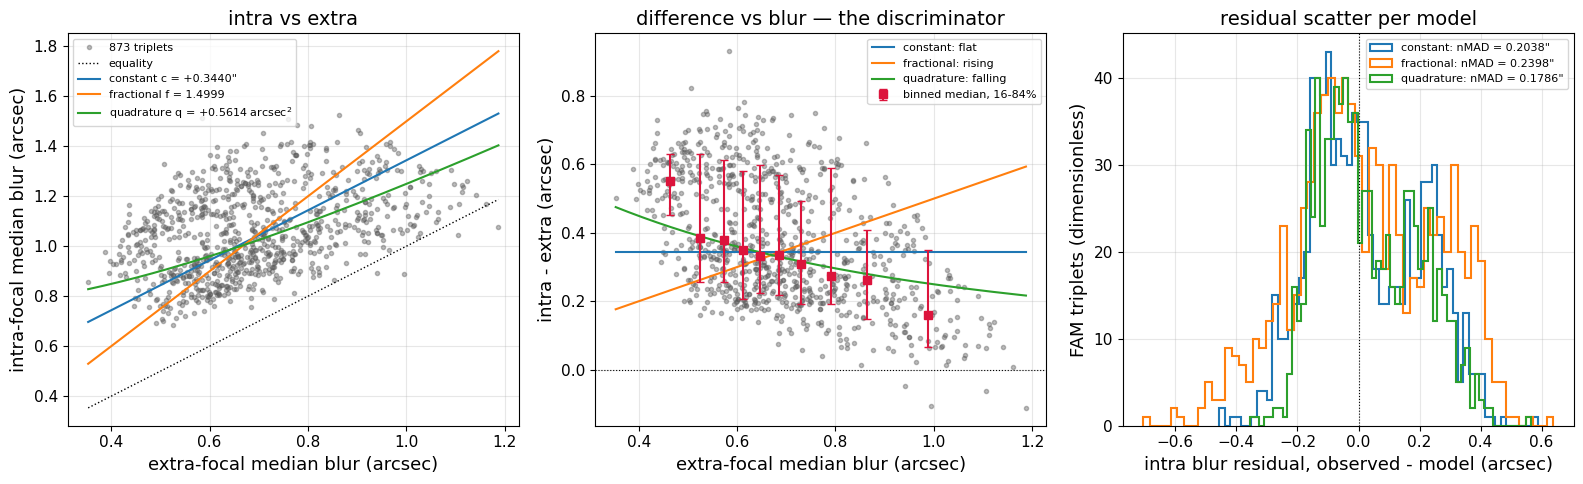

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

ok = np.isfinite(b_intra) & np.isfinite(b_extra)
bi, be = b_intra[ok], b_extra[ok]
grid = np.linspace(np.min(be), np.max(be), 200)

# Panel 1: intra against extra, with the three fitted relations.
ax = axs[0]
ax.plot(be, bi, linestyle='none', marker='o', markersize=3, alpha=0.4,
        color='0.35', label=f'{n_fit} triplets')
ax.plot(grid, grid, color='k', linewidth=1.0, linestyle=':', label='equality')
ax.plot(grid, grid + models['constant']['param'], color='#1f77b4', linewidth=1.5,
        label=f"constant c = {models['constant']['param']:+.4f}\"")
ax.plot(grid, models['fractional']['param'] * grid, color='#ff7f0e', linewidth=1.5,
        label=f"fractional f = {models['fractional']['param']:.4f}")
ax.plot(grid, np.sqrt(np.clip(grid**2 + models['quadrature']['param'], 0, None)),
        color='#2ca02c', linewidth=1.5,
        label=f"quadrature q = {models['quadrature']['param']:+.4f} arcsec$^2$")
ax.set_xlabel('extra-focal median blur (arcsec)')
ax.set_ylabel('intra-focal median blur (arcsec)')
ax.set_title('intra vs extra')
ax.legend(fontsize=8, loc='upper left')

# Panel 2: the discriminator — difference against extra blur.
ax = axs[1]
ax.plot(be, bi - be, linestyle='none', marker='o', markersize=3, alpha=0.4, color='0.35')
ax.axhline(0.0, color='k', linewidth=0.8, linestyle=':')
ax.plot(grid, np.full_like(grid, models['constant']['param']), color='#1f77b4',
        linewidth=1.5, label='constant: flat')
ax.plot(grid, (models['fractional']['param'] - 1.0) * grid, color='#ff7f0e',
        linewidth=1.5, label='fractional: rising')
ax.plot(grid, np.sqrt(np.clip(grid**2 + models['quadrature']['param'], 0, None)) - grid,
        color='#2ca02c', linewidth=1.5, label='quadrature: falling')

# Binned medians of the observed difference: the data's own answer, model-free.
edges = np.quantile(be, np.linspace(0, 1, 11))
centers, med, lo, hi = [], [], [], []
for a, b in zip(edges[:-1], edges[1:]):
    sel = (be >= a) & (be <= b) if b == edges[-1] else (be >= a) & (be < b)
    if sel.sum() >= 5:
        d = (bi - be)[sel]
        centers.append(float(np.median(be[sel])))
        med.append(float(np.median(d)))
        lo.append(float(np.percentile(d, 16)))
        hi.append(float(np.percentile(d, 84)))
med, lo, hi = np.array(med), np.array(lo), np.array(hi)
ax.errorbar(centers, med, yerr=[med - lo, hi - med], fmt='s', color='crimson',
            markersize=6, capsize=3, linewidth=1.5, label='binned median, 16-84%')
ax.set_xlabel('extra-focal median blur (arcsec)')
ax.set_ylabel('intra - extra (arcsec)')
ax.set_title('difference vs blur — the discriminator')
ax.legend(fontsize=8)

# Panel 3: residual distributions, one histogram per model.
ax = axs[2]
for name, color in (('constant', '#1f77b4'), ('fractional', '#ff7f0e'),
                    ('quadrature', '#2ca02c')):
    m = models[name]
    ax.hist(m['residual'], bins=60, histtype='step', linewidth=1.5, color=color,
            label=f"{name}: nMAD = {m['nmad_arcsec']:.4f}\"")
ax.axvline(0.0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel('intra blur residual, observed - model (arcsec)')
ax.set_ylabel('FAM triplets (dimensionless)')
ax.set_title('residual scatter per model')
ax.legend(fontsize=8)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_offset_models.pdf')
plt.show()


### Trend of the difference, quantified

The binned medians above are the direct test. Fitting a line to `intra - extra` against
extra blur separates the three models by its slope alone:

- slope ~ 0 with a non-zero intercept: **constant** offset
- slope ~ `f - 1` > 0 through the origin: **fractional** offset
- slope < 0: **quadrature** offset

Huber robust linear regression, the repository default for a calibration line of this
kind.


In [8]:
X = sm.add_constant(be)
rlm = sm.RLM(bi - be, X, M=sm.robust.norms.HuberT()).fit()
intercept, slope = float(rlm.params[0]), float(rlm.params[1])
intercept_err, slope_err = float(rlm.bse[0]), float(rlm.bse[1])

print(f'Huber RLM of (intra - extra) in arcsec on extra blur in arcsec, '
      f'n = {n_fit} triplets')
print(f'  intercept = {intercept:+.5f} +/- {intercept_err:.5f} arcsec')
print(f'  slope     = {slope:+.5f} +/- {slope_err:.5f} arcsec per arcsec '
      f'(dimensionless)')
print(f'  a fractional offset would predict slope = '
      f'{models["fractional"]["param"] - 1.0:+.5f} (dimensionless)')
print(f'  a constant offset would predict slope = +0.00000 (dimensionless)')

r, p_r = stats.pearsonr(be, bi - be)
rho, p_rho = stats.spearmanr(be, bi - be)
print(f'\n(intra - extra) in arcsec vs extra blur in arcsec, n = {n_fit} triplets:')
print(f'  Pearson r    = {r:+.4f} (p = {p_r:.3e})')
print(f'  Spearman rho = {rho:+.4f} (p = {p_rho:.3e})')

r2, p_r2 = stats.pearsonr(be, bi)
rho2, p_rho2 = stats.spearmanr(be, bi)
print(f'\nintra blur vs extra blur, both arcsec, n = {n_fit} triplets:')
print(f'  Pearson r    = {r2:+.4f} (p = {p_r2:.3e})')
print(f'  Spearman rho = {rho2:+.4f} (p = {p_rho2:.3e})')


Huber RLM of (intra - extra) in arcsec on extra blur in arcsec, n = 873 triplets
  intercept = +0.76206 +/- 0.02435 arcsec
  slope     = -0.57640 +/- 0.03444 arcsec per arcsec (dimensionless)
  a fractional offset would predict slope = +0.49989 (dimensionless)
  a constant offset would predict slope = +0.00000 (dimensionless)

(intra - extra) in arcsec vs extra blur in arcsec, n = 873 triplets:
  Pearson r    = -0.5061 (p = 5.627e-58)
  Spearman rho = -0.4830 (p = 3.181e-52)

intra blur vs extra blur, both arcsec, n = 873 triplets:
  Pearson r    = +0.4003 (p = 6.156e-35)
  Spearman rho = +0.3934 (p = 1.096e-33)


<a id='summary'></a>
## Summary


In [9]:
print(f'{PARAM_SET}: {n_fit} FAM triplets with a finite blur median on both sides\n')
print(f'median intra-focal blur     = {np.median(bi):.4f} arcsec')
print(f'median extra-focal blur     = {np.median(be):.4f} arcsec')
print(f'median (intra - extra)      = {np.median(bi - be):+.4f} arcsec')
print(f'median (intra / extra)      = {np.median(bi / be):.4f} (dimensionless)')
print(f'fraction with intra > extra = {float(np.mean(bi > be)):.4f} '
      f'(dimensionless, of {n_fit} triplets)\n')
for name in ('constant', 'fractional', 'quadrature'):
    m = models[name]
    print(f'{name:11s}: param = {m["param"]:+.5f} {m["param_units"]:28s} '
          f'resid nMAD = {m["nmad_arcsec"]:.5f} arcsec')
print(f'\nlowest robust residual scatter: {best}')
print(f'slope of (intra - extra) on extra blur = {slope:+.5f} +/- {slope_err:.5f} '
      f'(dimensionless)')


danish_1_3_test: 873 FAM triplets with a finite blur median on both sides

median intra-focal blur     = 1.0526 arcsec
median extra-focal blur     = 0.6636 arcsec
median (intra - extra)      = +0.3440 arcsec
median (intra / extra)      = 1.4999 (dimensionless)
fraction with intra > extra = 0.9954 (dimensionless, of 873 triplets)

constant   : param = +0.34395 arcsec                       resid nMAD = 0.20379 arcsec
fractional : param = +1.49989 dimensionless (intra/extra)  resid nMAD = 0.23984 arcsec
quadrature : param = +0.56140 arcsec**2                    resid nMAD = 0.17863 arcsec

lowest robust residual scatter: quadrature
slope of (intra - extra) on extra blur = -0.57640 +/- 0.03444 (dimensionless)
